<a href="https://colab.research.google.com/github/felipevergalr/calculo-numerico/blob/main/atividade_II_calculo_numerico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática II — Estabilidade e overflow


Felipe Pereira Vergal Rostirola 185210


## 1. Verificação da estabilidade

$$\Delta y=\frac{0{,}01}{21-1}=0{,}0005\ \text{m}$$
$$\Delta t_{max}=\frac{(0{,}0005)^2}{2\cdot10^{-4}}=0{,}00125\ \text{s}$$


**Caso A:** $r=10^{-4}\cdot0{,}001/(0{,}0005)^2=0{,}4$. Estável, pois $r\leq0{,}5$.

**Caso B:** $r=10^{-4}\cdot0{,}002/(0{,}0005)^2=0{,}8$. Instável, pois $r>0{,}5$.

## 2. Detecção de overflow

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)
    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (u[2:] - dois * u[1:-1] + u[:-2])
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"dt={dt}, {tipo.__name__}: {passos} passos sem overflow.")
    return {
        "y": y, "u": u, "tempos": tempos,
        "maximos": maximos, "r": float(r), "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)
resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


| Tipo numérico | Δt (s) | r | Overflow | Iteração da falha |
|---|---:|---:|---|---:|
| float32 | 0.001 | 0.4 | Não | — |
| float32 | 0.002 | 0.8 | Sim | 121 |
| float64 | 0.001 | 0.4 | Não | — |
| float64 | 0.002 | 0.8 | Sim | 917 |

Cada teste foi limitado a 2.000 passos. A iteração da falha é a atualização que gerou a exceção; o último perfil armazenado é o do passo anterior.

In [2]:
print(f"{'Tipo':<10} {'dt (s)':>8} {'r':>6} {'Overflow':>10} {'Iteracao':>10}")
for nome, resultado in resultados.items():
    tipo, dt = nome.split(", dt=")
    falha = resultado["falha"]
    print(f"{tipo:<10} {dt:>8} {resultado['r']:>6.1f} "
          f"{'Sim' if falha else 'Nao':>10} {str(falha) if falha else '-':>10}")

Tipo         dt (s)      r   Overflow   Iteracao
float32       0.001    0.4        Nao          -
float32       0.002    0.8        Sim        121
float64       0.001    0.4        Nao          -
float64       0.002    0.8        Sim        917


## 3. Interpretação física

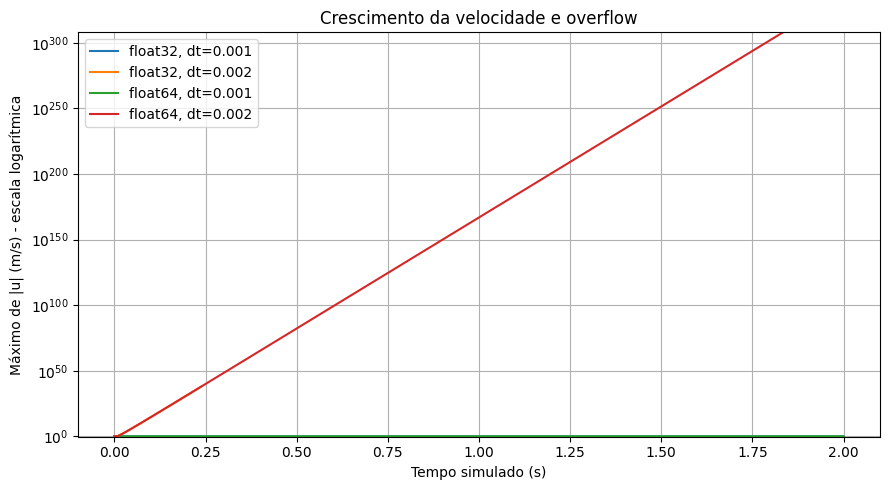

In [3]:
plt.figure(figsize=(9, 5))
plt.ylim(0.5, 1e308)
for nome, resultado in resultados.items():
    plt.semilogy(resultado["tempos"], resultado["maximos"], label=nome)
# Limites e marcas explicitos evitam overflow na escala do grafico.
from matplotlib.ticker import FixedLocator, NullLocator
plt.ylim(0.5, 1e308)
plt.gca().yaxis.set_major_locator(FixedLocator([10.0**e for e in range(0, 301, 50)]))
plt.gca().yaxis.set_minor_locator(NullLocator())
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) - escala logarítmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

No caso A, o máximo permanece em 1 m/s, porque a placa móvel mantém essa velocidade e o interior fica entre 0 e 1 m/s. As duas curvas estáveis ficam sobrepostas.

No caso B, as oscilações crescem e produzem velocidades fora desse intervalo. Esse crescimento é causado pela instabilidade do método, não pelo movimento físico do fluido. A solução já está incorreta antes do overflow. As curvas instáveis terminam no último passo calculado sem exceção.

## 4. Capacidade de representação

O `float32` representa valores finitos até aproximadamente $3{,}4\times10^{38}$, enquanto o `float64` chega a $1{,}8\times10^{308}$. Por isso, o `float64` suporta mais passos de crescimento antes do overflow.

A mudança de tipo não elimina a instabilidade: o caso B continua com $r=0{,}8>0{,}5$. Ela apenas adia a falha. A instabilidade é o crescimento indevido dos erros; o overflow ocorre quando uma operação ultrapassa a faixa representável.

## 5. Refinamento da malha

Com 41 pontos:
$$\Delta y=\frac{0{,}01}{41-1}=0{,}00025\ \text{m}$$
$$\Delta t_{max}=\frac{(0{,}00025)^2}{2\cdot10^{-4}}=0{,}0003125\ \text{s}$$

Mantendo $\Delta t=0{,}001$ s, obtemos $r=1{,}6$: o teste fica instável.

Escolhendo $\Delta t=0{,}00025$ s, abaixo do novo limite, obtemos $r=0{,}4$: o teste fica estável.

In [ ]:
refinado_instavel = simular(0.001, pontos=41)
refinado_estavel = simular(0.00025, pontos=41)
for nome, resultado in [("Malha refinada, dt=0.001", refinado_instavel),
                        ("Malha refinada, dt=0.00025", refinado_estavel)]:
    print(f"{nome}: r={resultado['r']:.1f}, "
          f"maximo final={resultado['maximos'][-1]:.6g} m/s")

dt=0.001, float32: falha no passo 56, t=0.0560 s - overflow encountered in multiply
dt=0.00025, float32: 2000 passos sem overflow.
Malha refinada, dt=0.001: r=1.6, maximo final=7.07957e+37 m/s
Malha refinada, dt=0.00025: r=0.4, maximo final=1 m/s


Ao reduzir o espaçamento pela metade, o limite de tempo fica quatro vezes menor. Manter o passo anterior provoca instabilidade e overflow. Com o passo reduzido para 0,00025 s, o teste termina sem overflow e a maior velocidade permanece em 1 m/s.

## 6. Verificação do perfil de velocidade

Tempo simulado: 2.000 s
Diferenca maxima E_inf: 1.605312e-09 m/s


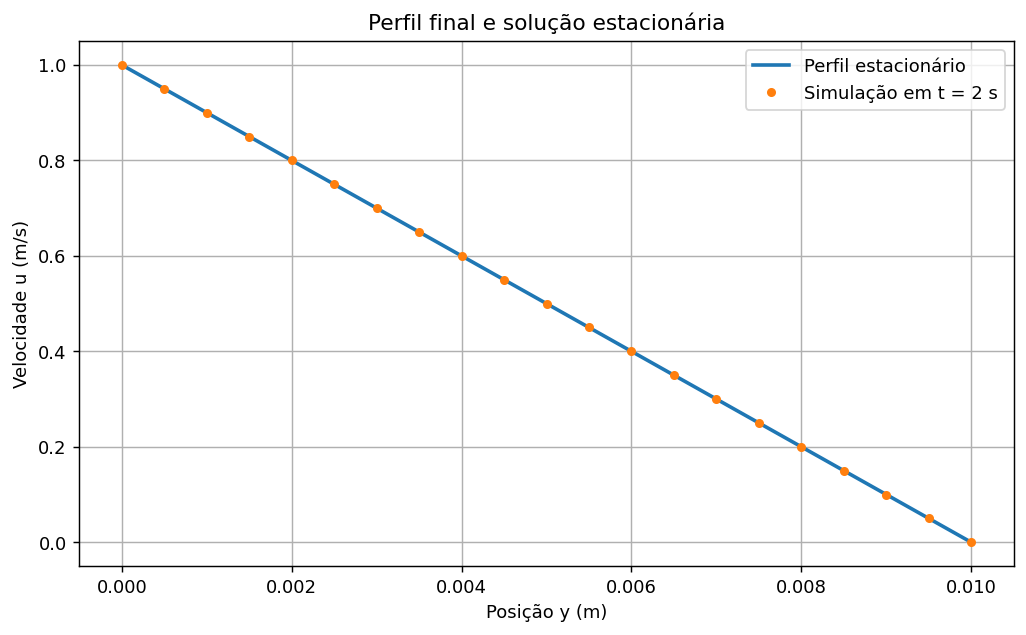

In [ ]:
# Caso A em float64: 2000 passos de 0.001 s = 2 s.
resultado = resultados["float64, dt=0.001"]
y = resultado["y"]
u = resultado["u"]
H = 0.01
U = 1.0
u_est = U * (1 - y / H)
erro = np.max(np.abs(u - u_est))
print(f"Tempo simulado: {resultado['tempos'][-1]:.3f} s")
print(f"Diferenca maxima E_inf: {erro:.6e} m/s")

plt.figure(figsize=(8, 5))
plt.plot(y, u_est, label="Perfil estacionário", linewidth=2)
plt.plot(y, u, "o", label="Simulação em t = 2 s", markersize=4)
plt.xlabel("Posição y (m)")
plt.ylabel("Velocidade u (m/s)")
plt.title("Perfil final e solução estacionária")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

A diferença máxima foi $E_\infty=1.605312e-09$ m/s. Os perfis praticamente coincidem: a velocidade diminui de 1 m/s na placa móvel até zero na placa fixa.

O tempo de 2 s foi suficiente para aproximar o regime estacionário. A diferença calculada pode incluir o transiente residual e os erros numéricos; a expressão estacionária não descreve os instantes iniciais da simulação.

## 7. Conclusão

Refinar a malha exige reduzir o passo de tempo, pois o limite de estabilidade é proporcional ao quadrado do espaçamento. Se esse limite for ultrapassado, os erros podem crescer, gerar velocidades não físicas e posteriormente causar overflow.

Usar `float64` adia o overflow, mas não corrige a instabilidade. A causa da falha foi corrigida reduzindo o passo de tempo para garantir $r\leq0{,}5$: 0,001 s com 21 pontos e 0,00025 s com 41 pontos.